<a href="https://colab.research.google.com/github/meryambutt123-a11y/urdu-ocr-codesaviours-si26-maryam/blob/main/SI26-Week1-maryam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Week 1: Urdu OCR Setup

# **What is OCR (Optical Character Recognition)?**
Optical Character Recognition (OCR) is a computer vision technology that converts images of typed, handwritten, or printed text into machine-readable digital text. Instead of simply viewing a document as a static picture, an OCR system acts like a human eye to recognize the unique shapes of individual letters and words. Once the text is successfully extracted, computers can process it just like a standard text file, allowing users to edit the content, search for keywords, or feed the data into other artificial intelligence models.

# **Why is Urdu OCR harder than English OCR?**
Urdu OCR presents significant technical challenges primarily because it is written in the complex, cursive Nastaliq script where letters connect dynamically. Unlike English, which consists of distinct, isolated letters printed horizontally on a straight baseline, Urdu characters physically change their shape depending on whether they appear at the beginning, middle, or end of a word. Furthermore, Urdu text relies heavily on overlapping strokes and tiny dots (nuqtas) that drastically alter a word's meaning, making it incredibly difficult for standard algorithms to segment and recognize individual characters accurately.

# **What are 2 real-world situations where Urdu OCR would be useful?**
One major application of Urdu OCR is the mass digitization of historical archives and literature, making decades of printed books, newspapers, and poetry globally searchable and accessible for modern readers. A second vital use case is automating administrative workflows within legal and government sectors, allowing physical forms, national identity cards, and legal rulings to be instantly scanned into searchable digital databases. Implementing OCR in these situations drastically reduces the need for manual data entry, saving thousands of hours while preserving important physical documents from permanent loss.


In [2]:
import os

# This is your permanent folder in Google Drive
base_path = '/content/drive/MyDrive/Urdu_OCR_Project'

folders = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/other'
]

for folder in folders:
    # This forces the folders to be created inside your Drive
    full_path = os.path.join(base_path, folder)
    os.makedirs(full_path, exist_ok=True)
    print(f'Created: {full_path}')

print('Permanent folder structure ready!')

Created: /content/drive/MyDrive/Urdu_OCR_Project/data/raw/newspaper
Created: /content/drive/MyDrive/Urdu_OCR_Project/data/raw/books
Created: /content/drive/MyDrive/Urdu_OCR_Project/data/raw/signboards
Created: /content/drive/MyDrive/Urdu_OCR_Project/data/raw/synthetic
Created: /content/drive/MyDrive/Urdu_OCR_Project/data/raw/other
Permanent folder structure ready!


In [6]:
import os
import shutil

# Your permanent base path
base_path = '/content/drive/MyDrive/Urdu_OCR_Project'

# This tells the script which temporary folder goes to which permanent folder
folder_mapping = {
    'AAA': 'other',
    'BBB': 'books',
    'CCC': 'signboards',
    'DDD': 'newspaper'
}

for source, target in folder_mapping.items():
    source_path = f'/content/{source}'
    target_path = os.path.join(base_path, f'data/raw/{target}')

    if os.path.exists(source_path):
        files = sorted([f for f in os.listdir(source_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

        if len(files) > 0:
            for i, filename in enumerate(files, 1):
                ext = os.path.splitext(filename)[1]
                new_name = f'{target}_{i}{ext}'

                old_file = os.path.join(source_path, filename)
                new_file = os.path.join(target_path, new_name)

                shutil.move(old_file, new_file)
            print(f'✅ Successfully moved and renamed {len(files)} images from {source} ➔ {target}')
        else:
            print(f'⚠️ Folder {source} is empty.')
    else:
        print(f'⚠️ Skipped {source}: Folder not found in temporary storage (already moved or missing).')

print('\nImage moving process complete!')

⚠️ Skipped AAA: Folder not found in temporary storage (already moved or missing).
⚠️ Skipped BBB: Folder not found in temporary storage (already moved or missing).
⚠️ Skipped CCC: Folder not found in temporary storage (already moved or missing).
⚠️ Skipped DDD: Folder not found in temporary storage (already moved or missing).

Image moving process complete!


In [4]:
!wget -q "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/unhinted/ttf/NotoNastaliqUrdu/NotoNastaliqUrdu-Regular.ttf" -O urdu_font.ttf

import os
from PIL import Image, ImageDraw, ImageFont

# 1. Point to your permanent Drive folder
base_path = '/content/drive/MyDrive/Urdu_OCR_Project'
synthetic_folder = os.path.join(base_path, 'data/raw/synthetic')

urdu_texts = [
    "پاکستان زندہ باد",
    "آج کا موسم خوشگوار ہے",
    "تعلیم ہر انسان کا حق ہے",
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "محنت کامیابی کی کنجی ہے",
    "علم ایک عظیم طاقت ہے",
    "ہمیشہ سچ بولنا چاہیے",
    "کتابیں انسان کی بہترین دوست ہیں",
    "وقت کی قدر کرنا سیکھیں",
    "پانی زندگی کے لیے بے حد ضروری ہے",
    "ورزش صحت کے لیے مفید ہے",
    "دوسروں کی مدد کرنا نیکی ہے",
    "درخت لگانا صدقہ جاریہ ہے",
    "سادگی میں حسن ہے",
    "محنتی طالب علم ہمیشہ کامیاب ہوتا ہے",
    "رات کے وقت آسمان پر ستارے چمکتے ہیں",
    "صبح سویرے اٹھنا صحت کے لیے اچھا ہے",
    "علامہ اقبال ہمارے قومی شاعر ہیں",
    "استاد کا احترام سب پر فرض ہے",
    "صبر کا پھل ہمیشہ میٹھا ہوتا ہے"
]

# 2. Make sure the folder exists in Drive
os.makedirs(synthetic_folder, exist_ok=True)
urdu_font = ImageFont.truetype("urdu_font.ttf", 40)

for i, text in enumerate(urdu_texts):
    img = Image.new('RGB', (900, 150), color='white')
    draw = ImageDraw.Draw(img)

    draw.text((880, 50), text, fill='black', font=urdu_font, anchor="rt", direction='rtl', language='ur')

    # 3. Save the image straight to Google Drive
    save_path = os.path.join(synthetic_folder, f'urdu_{i+1}.png')
    img.save(save_path)
    print(f'✅ Generated {i+1}/20: urdu_{i+1}.png')

print('\nDone! 20 synthetic images successfully generated and locked safely in your Google Drive!')

✅ Generated 1/20: urdu_1.png
✅ Generated 2/20: urdu_2.png
✅ Generated 3/20: urdu_3.png
✅ Generated 4/20: urdu_4.png
✅ Generated 5/20: urdu_5.png
✅ Generated 6/20: urdu_6.png
✅ Generated 7/20: urdu_7.png
✅ Generated 8/20: urdu_8.png
✅ Generated 9/20: urdu_9.png
✅ Generated 10/20: urdu_10.png
✅ Generated 11/20: urdu_11.png
✅ Generated 12/20: urdu_12.png
✅ Generated 13/20: urdu_13.png
✅ Generated 14/20: urdu_14.png
✅ Generated 15/20: urdu_15.png
✅ Generated 16/20: urdu_16.png
✅ Generated 17/20: urdu_17.png
✅ Generated 18/20: urdu_18.png
✅ Generated 19/20: urdu_19.png
✅ Generated 20/20: urdu_20.png

Done! 20 synthetic images successfully generated and locked safely in your Google Drive!


In [ ]:
import os
import shutil

source_folder = 'AAA'
target_folder = 'data/raw/other'

# Count how many images are ALREADY in the target folder so we don't overwrite them
existing_images = [f for f in os.listdir(target_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))] if os.path.exists(target_folder) else []
start_count = len(existing_images)

files = sorted(os.listdir(source_folder))

image_count = start_count
moved_count = 0

for filename in files:
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_count += 1
        moved_count += 1

        file_extension = os.path.splitext(filename)[1]
        # This will cleanly name them other_21.jpg, other_22.jpg, etc.
        new_name = f'other_{image_count}{file_extension}'

        old_path = os.path.join(source_folder, filename)
        new_path = os.path.join(target_folder, new_name)

        shutil.move(old_path, new_path)
        print(f'Successfully moved: {filename} ➔ {new_name}')

print(f'\nDone! Added {moved_count} new images. Total in folder now: {image_count}')

Successfully moved: img (1946).jpg ➔ other_21.jpg
Successfully moved: img (1957).jpg ➔ other_22.jpg
Successfully moved: img (1979).jpg ➔ other_23.jpg
Successfully moved: img (2480).jpg ➔ other_24.jpg
Successfully moved: img (2502).jpg ➔ other_25.jpg
Successfully moved: img (2524).jpg ➔ other_26.jpg
Successfully moved: img (2535).jpg ➔ other_27.jpg
Successfully moved: img (2546).jpg ➔ other_28.jpg
Successfully moved: img (2558).jpg ➔ other_29.jpg
Successfully moved: img (2569).jpg ➔ other_30.jpg

Done! Added 10 new images. Total in folder now: 30


In [7]:
import os
import pandas as pd

base_path = '/content/drive/MyDrive/Urdu_OCR_Project'
data_folders = ['newspaper', 'books', 'signboards', 'synthetic', 'other']
all_data = []

# Scan the permanent folders and grab every image
for folder in data_folders:
    folder_path = os.path.join(base_path, 'data/raw', folder)
    if os.path.exists(folder_path):
        # Sort files so they appear in perfect order (e.g., book_1, book_2)
        files = sorted(os.listdir(folder_path))
        for filename in files:
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Write the exact path the model will need
                relative_path = f'data/raw/{folder}/{filename}'
                all_data.append({'image': relative_path, 'text': ''})

# Create the CSV
if all_data:
    df = pd.DataFrame(all_data)
    csv_path = os.path.join(base_path, 'labels.csv')
    df.to_csv(csv_path, index=False)
    print(f"✅ SUCCESS! labels.csv created permanently in your Drive with {len(df)} rows.")
else:
    print("⚠️ No images found. Make sure you drag-and-dropped the images into the Drive folders first!")

✅ SUCCESS! labels.csv created permanently in your Drive with 140 rows.


--- DATASET STATUS ---
Total images: 139
Empty labels (needs fixing if > 0): 0
----------------------



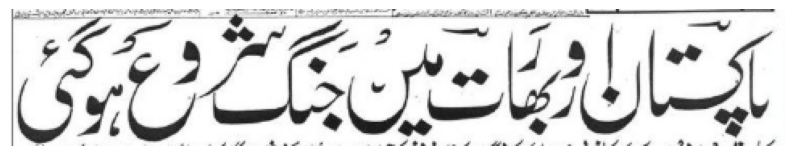

📝 Urdu Label from your PC file: پاکستان بھارت میں جنگ شروع ہوگئی


In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load your finished CSV from Drive
base_path = '/content/drive/MyDrive/Urdu_OCR_Project'
csv_path = os.path.join(base_path, 'labels.csv')

df = pd.read_csv(csv_path)

print("--- DATASET STATUS ---")
print(f"Total images: {len(df)}")
print(f"Empty labels (needs fixing if > 0): {df['text'].isna().sum()}")
print("----------------------\n")

# 2. Let's look at the very first image and its label!
# Grab the path and text from the first row (index 0)
first_img_relative_path = df.iloc[0]['image']
first_text = df.iloc[0]['text']

# Open the actual image
full_img_path = os.path.join(base_path, first_img_relative_path)
img = Image.open(full_img_path)

# Show the image and print the text
plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

print(f"📝 Urdu Label from your PC file: {first_text}")